# Spider Silk Stretching

https://doi.org/10.1021/acs.biomac.7b00086

<img src="https://pubs.acs.org/cms/10.1021/acs.biomac.7b00086/asset/images/medium/bm-2017-00086f_0001.gif" width="300">

# Libraries & Set up

In [1]:
%run ../../../setup_workspace.py # ../ means level up 

✓ Workspace ready


# Data

In [2]:
# SC5711 Data - Sergei Chvalun data

## Stretching
poni = '/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Linkam_2DWAXS_13keV_300mm.poni'
ai = pyFAI.load(poni)

In [3]:
# Mask file 
mask = "/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/MASK_Stretcher.edf"
file_mask = mask
img_mask = fabio.open(mask).data

In [4]:
# 2D data
Exp0 = BM26_experiment('/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Stretcher_Sergei_silk_RT_bis_0mm')

Exp0p5 = BM26_experiment('/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Stretcher_Sergei_silk_RT_bis_0_5mm')
Exp0p5_back = BM26_experiment('/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Stretcher_Sergei_silk_RT_bis_0_5mm_back')

Exp1p5 = BM26_experiment('/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Stretcher_Sergei_silk_RT_bis_1_5mm')
Exp1p5_forth = BM26_experiment('/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Stretcher_Sergei_silk_RT_bis_1_5mm_forth')

Exp2 = BM26_experiment('/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Stretcher_Sergei_silk_RT_bis_2_0mm')

# Functions

In [5]:
from pyFAI.gui import jupyter
# ... any functions for analysis

# Analysis

### 1D integration

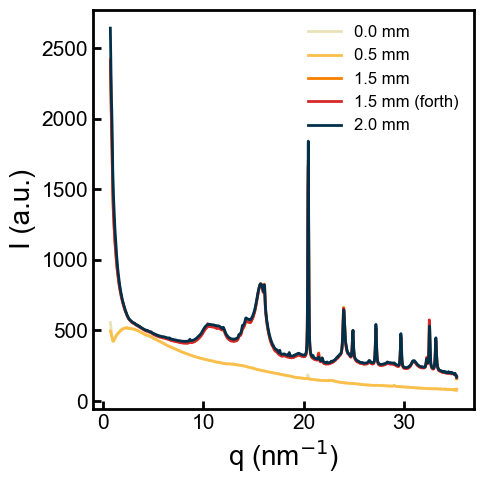

In [6]:
# Set global font to Arial and style for publication
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6

fig, ax = plt.subplots(1,1, figsize=(5,5))

# Your data plotting
q, I_array = Exp0.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')
plt.plot(q, I_array[0], color='#eae2b7', label='0.0 mm', linewidth=2)

q, I_array = Exp0p5.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')
plt.plot(q, I_array[0], color='#fcbf49', label='0.5 mm', linewidth=2)

q, I_array = Exp0p5_back.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')
#plt.plot(q, I_array[0] * 1, color='')

q, I_array = Exp1p5.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')
plt.plot(q, I_array[0], color='#f77f00', label='1.5 mm', linewidth=2)

q, I_array = Exp1p5_forth.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')
plt.plot(q, I_array[0], color='#d62828', label='1.5 mm (forth)', linewidth=2)

q, I_array = Exp2.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')
plt.plot(q, I_array[0], color='#003049', label='2.0 mm', linewidth=2)

plt.xlabel('q (nm$^{-1}$)', fontname='Arial', fontsize=20)  # ← Markdown для степени
plt.ylabel('I (a.u.)', fontname='Arial', fontsize=20)

plt.legend(frameon=False, fontsize=12)

ax.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.show()

probably only 1.5 and 2 mm samples were transmitted with a beam. 

In [7]:
Exp2.get_Tr_profile() # Transmission

[1.4309286333926863, 1.4318147708687425]

##### All experiments 

/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Stretcher_Sergei_silk_150C_secondsample_0_25mm
/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Stretcher_Sergei_silk_150C_secondsample_0_5mm
/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Stretcher_Sergei_silk_150C_secondsample_0_75mm
/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Stretcher_Sergei_silk_150C_secondsample_0mm
/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Stretcher_Sergei_silk_RT
/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Stretcher_Sergei_silk_RT_0_25mm
/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Stretcher_Sergei_silk_RT_0_50mm
/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Stretcher_Sergei_silk_RT_0_75mm
/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Stretcher_Sergei_silk_RT_bis_0_5mm
/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Stretcher_Sergei_silk_RT_bis_0mm
/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Stretcher_Sergei_silk_RT_bisbis_0_5mm
/Users

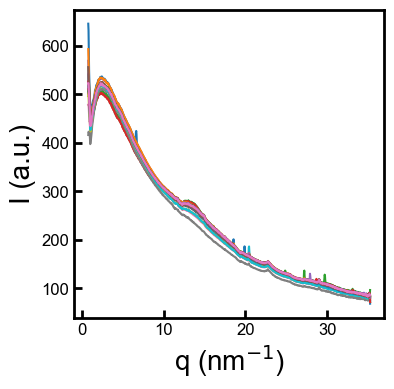

In [29]:
fig, ax = plt.subplots(1,1, figsize=(4,4))

paths = list_experiments('/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk') # all session

for path in paths:
    Exp = BM26_experiment(path)
    q, I_array = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')
    if max(I_array[0]) <= 1000:
        plt.plot(q, I_array[0])
        print(path)
    
    
plt.xlabel('q (nm$^{-1}$)', fontname='Arial', fontsize=20)  # ← Markdown для степени
plt.ylabel('I (a.u.)', fontname='Arial', fontsize=20)


plt.savefig('All_experiments_1D.png', dpi=300, bbox_inches='tight', transparent=True)

### 2D integration

##### 2mm

In [8]:
res = Exp2.integrate2d_SAXS(ai, 1000, unit='q_nm^-1', azim=False)
#jupyter.plot2d(res[0])

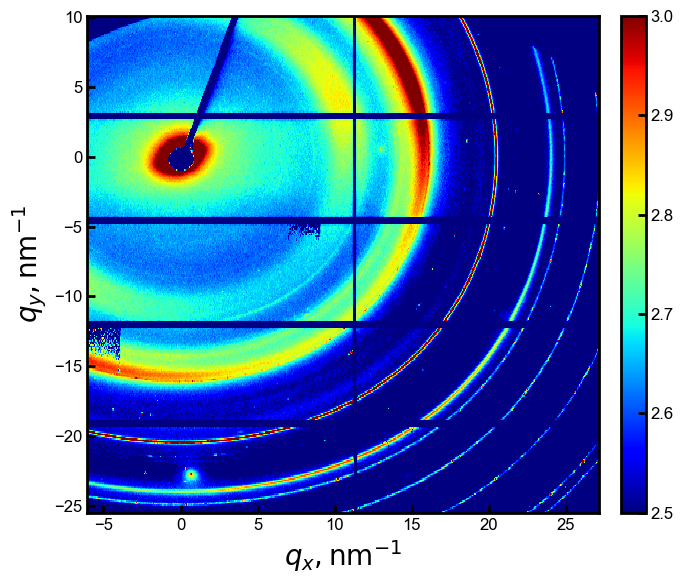

In [9]:
fig, ax1 = plt.subplots(1, 1, figsize=(7,6), layout='tight')

cmap = plt.cm.jet

cmap.set_bad(color='black')  # для NaN
cmap.set_over(color='black')  # для значений > vmax
cmap.set_under(color='black') # для значений < vmin

mesh = ax1.pcolormesh(res[0][1], res[0][2], np.log10(res[0][0]+ 1e-10), vmin=2.5, vmax=3., cmap='jet',rasterized=True)


ax1.set_xlabel('$q_{x},\\mathrm{nm}^{-1}$', fontsize=20, fontname='Arial', fontweight='bold')
ax1.set_ylabel('$q_{y},\\mathrm{nm}^{-1}$', fontsize=20, fontname='Arial', fontweight='bold')
#ax1.set_xlim(min(y), 0.9)
#ax1.set_ylim(min(y), 0.9)
cbar = fig.colorbar(mesh, ax=ax1, fraction=0.046, pad=0.04)

plt.savefig('Silk_bis_2mm_2D_plot.png', dpi=300, bbox_inches='tight', transparent=True)

##### 0.5 back

In [25]:
res = Exp0p5_back.integrate2d_SAXS(ai, 1000, unit='q_nm^-1', azim=False)
#jupyter.plot2d(res[0])

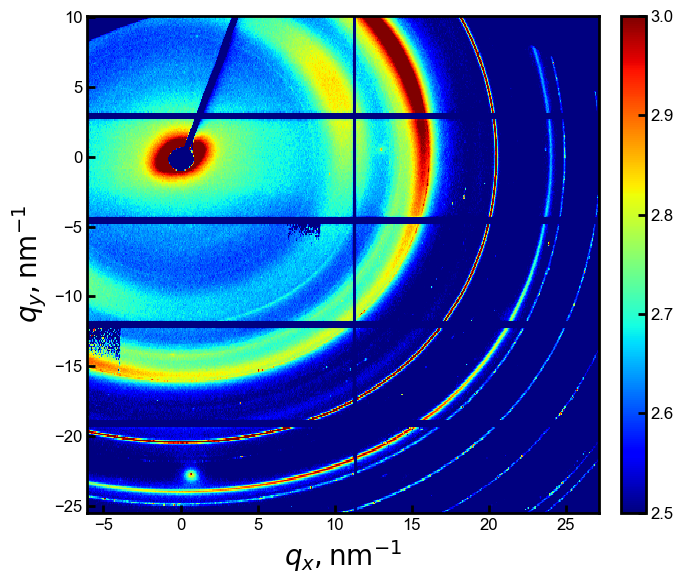

In [26]:
fig, ax1 = plt.subplots(1, 1, figsize=(7,6), layout='tight')

cmap = plt.cm.jet

cmap.set_bad(color='black')  # для NaN
cmap.set_over(color='black')  # для значений > vmax
cmap.set_under(color='black') # для значений < vmin

mesh = ax1.pcolormesh(res[0][1], res[0][2], np.log10(res[0][0]+ 1e-10), vmin=2.5, vmax=3., cmap='jet',rasterized=True)


ax1.set_xlabel('$q_{x},\\mathrm{nm}^{-1}$', fontsize=20, fontname='Arial', fontweight='bold')
ax1.set_ylabel('$q_{y},\\mathrm{nm}^{-1}$', fontsize=20, fontname='Arial', fontweight='bold')
#ax1.set_xlim(min(y), 0.9)
#ax1.set_ylim(min(y), 0.9)
cbar = fig.colorbar(mesh, ax=ax1, fraction=0.046, pad=0.04)

plt.savefig('Silk_bis_0p5mm_2D_plot.png', dpi=300, bbox_inches='tight', transparent=True)

#### Another experiment

In [55]:
Exp = BM26_experiment('/Users/akmalumarov/Yandex.Disk.localized/Sergei_silk/Stretcher_Sergei_silk_RT_secondsample_0_25mm')

res = Exp.integrate2d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1', azim=False)

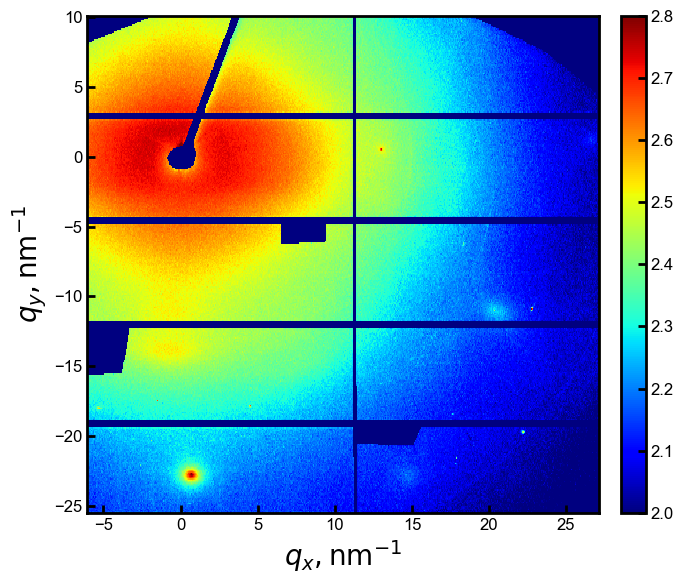

In [60]:
fig, ax1 = plt.subplots(1, 1, figsize=(7,6), layout='tight')

cmap = plt.cm.jet

cmap.set_bad(color='black')  # для NaN
cmap.set_over(color='black')  # для значений > vmax
cmap.set_under(color='black') # для значений < vmin

mesh = ax1.pcolormesh(res[0][1], res[0][2], np.log10(res[0][0]+ 1e-10), vmin=2., vmax=2.8, cmap='jet',rasterized=True)


ax1.set_xlabel('$q_{x},\\mathrm{nm}^{-1}$', fontsize=20, fontname='Arial', fontweight='bold')
ax1.set_ylabel('$q_{y},\\mathrm{nm}^{-1}$', fontsize=20, fontname='Arial', fontweight='bold')
#ax1.set_xlim(min(y), 0.9)
#ax1.set_ylim(min(y), 0.9)
cbar = fig.colorbar(mesh, ax=ax1, fraction=0.046, pad=0.04)

plt.savefig('Silk_RT.png', dpi=300, bbox_inches='tight', transparent=True)